In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data extraction
import kagglehub

import os
import glob


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Timing
import time

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Imbalanced Learning
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import ClusterCentroids
from imblearn.combine import SMOTETomek

# Feature Extraction
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
import shap

# Misc
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid")

In [3]:
# Download latest version if it doesn't exist yet
dataset_key = "mlg-ulb/creditcardfraud"
csv_name = "creditcardfraud.csv"

if not os.path.exists(csv_name):
    path = kagglehub.dataset_download(dataset_key)
else:
    path = csv_name

csv_files = glob.glob(path + "/**/*.csv", recursive=True)
print(csv_files)
df = pd.read_csv(csv_files[0])

print("Dataset Shape:", df.shape)

df.head()

['C:\\Users\\Daniel\\.cache\\kagglehub\\datasets\\mlg-ulb\\creditcardfraud\\versions\\3\\creditcard.csv']
Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print(df.info())
print(df.describe())

# Check for missing values
print("Missing Values:\n", df.isnull().sum()) 

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

Class
0    284315
1       492
Name: count, dtype: int64


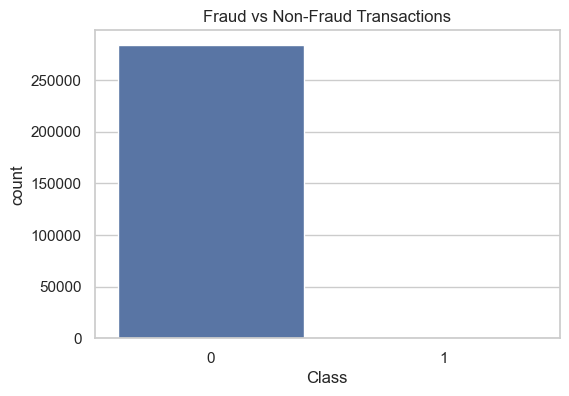

Fraud Percentage: 0.1727%


In [5]:
class_counts = df["Class"].value_counts()

print(class_counts)

plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

fraud_percentage = (
    df["Class"].sum() / len(df)
) * 100

print(f"Fraud Percentage: {fraud_percentage:.4f}%")


**Observations:**

1. Dataset contains **284,807 transactions**.
2. Fraud transactions represent only **0.1727%** of the dataset.



## Model Factory Function

Creates all classifiers used in the project for fraud detection under strong class imbalance.

We use multiple models to compare how different learning approaches behave under imbalanced data, where false negatives (missed fraud) are more costly than false positives.

To address this, we use **class weighting**, which increases the importance of fraud samples during training by scaling their contribution to the loss. This shifts models toward detecting fraud more aggressively.

---

### Models included

#### K-Nearest Neighbors (KNN)
- Baseline distance-based model
- No class weighting support
- Imbalance handled indirectly via scaling and threshold tuning

#### Logistic Regression
- Linear model with probability output
- Supports `class_weight`
- Trained with weighted loss to prioritize fraud detection

#### Random Forest
- Tree ensemble model
- Supports `class_weight`
- Uses weighted impurity in split decisions

#### AdaBoost
- Boosting ensemble model
- Uses `sample_weight` instead of `class_weight`
- Fraud samples are given higher weight during boosting to force focus on minority class

In [ ]:
def create_models(random_state=42, class_weight=None):
    """
    Creates and returns all classifiers used in the project.
    class_weight: dict like {0:1, 1:10} or "balanced"
    """

    models = {
        "KNN": KNeighborsClassifier(
            n_neighbors=5
        ),

        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            random_state=random_state,
            class_weight=class_weight
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            random_state=random_state,
            n_jobs=-1,
            class_weight=class_weight
        ),

        "AdaBoost": AdaBoostClassifier(
            n_estimators=100,
            random_state=random_state
        )
    }

    return models

## Data Balancing Factory Function (Q1)

This function creates and returns all balancing techniques used to handle class imbalance in the dataset.

### Methods included:
- None (no balancing)
- Undersampling (RandomUnderSampler)
- SMOTE (Synthetic Minority Over-sampling Technique)
- SMOTE-Tomek (hybrid approach combining SMOTE and Tomek links)

In [ ]:
def create_balancing_methods(random_state=42):

    return {
        "None": None,

        "Undersampling": RandomUnderSampler(
            random_state=random_state
        ),

        "SMOTE": SMOTE(
            random_state=random_state
        ),

        "SMOTE_Tomek": SMOTETomek(
            random_state=random_state
        ),
        "ClusterCentroids": ClusterCentroids(
            random_state=random_state
        )
    }

## Threshold Optimization for Recall Bias

In fraud detection, it is preferable to incorrectly flag a transaction as fraud
rather than miss an actual fraudulent transaction.

Therefore, we adjust the decision threshold of the model to prioritize recall.

Recall is defined as:

Recall = TP / (TP + FN)

By maximizing recall, we minimize false negatives (missed fraud cases),
which is critical in real-world fraud detection systems.

We therefore select the smallest threshold that satisfies a target recall,
making the classifier more sensitive to fraud predictions.

In [ ]:
def find_threshold_for_target_recall(y_true, y_proba, target_recall=0.95):
    """
    Returns the lowest threshold that achieves target recall.
    If not achievable, returns the smallest possible threshold.
    """

    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    # align sizes (recall has +1 element vs thresholds)
    recall = recall[:-1]

    valid_idx = np.where(recall >= target_recall)[0]

    if len(valid_idx) > 0:
        # pick highest threshold that still satisfies recall
        best_idx = valid_idx[-1]
        return thresholds[best_idx]
    
    # fallback: most aggressive (catch everything)
    return thresholds[np.argmin(recall)]

## Apply Balancing To Data

Function to apply the balance methods to the data before running models

In [ ]:
def apply_balancing(X_train, y_train, method):
    """
    Applies balancing ONLY on training data.
    """

    if method is None:
        return X_train, y_train

    X_res, y_res = method.fit_resample(X_train, y_train)

    return X_res, y_res

### Feature Importance Extraction (Q2+3)

This function extracts feature importance from trained models.

- Random Forest / AdaBoost → uses built-in `feature_importances_`
- Logistic Regression → uses absolute values of coefficients

Output:
A sorted table of features ranked by importance, showing how strongly each feature influences predictions.

In [ ]:
def extract_feature_importance(model, feature_names, model_name="model"):
    """
    Extracts feature importance from supported models:
    - RandomForest
    - AdaBoost
    - Logistic Regression
    """

    importance = None

    # Tree-based models
    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_

    # Linear models
    elif hasattr(model, "coef_"):
        importance = np.abs(model.coef_).ravel()

    else:
        raise ValueError(f"Model {model_name} does not support feature importance extraction")

    df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })

    df = df.sort_values("importance", ascending=False).reset_index(drop=True)

    return df

### SHAP Feature Analysis

SHAP helps explaining model predictions by assigning each feature a contribution value.

- `compute_shap_values`: calculates SHAP values for each prediction
- `shap_global_importance`: aggregates SHAP values into global feature importance

Output:
- Local explanations (per prediction)
- Global feature ranking (mean absolute SHAP value)


In [ ]:
def compute_shap_values(model, X_train, X_test):
    """
    Computes SHAP values depending on model type.
    """

    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_test)

    return shap_values


def shap_global_importance(shap_values, feature_names):
    """
    Converts SHAP values into global feature importance.
    """

    importance = np.abs(shap_values.values).mean(axis=0)

    df = pd.DataFrame({
        "feature": feature_names,
        "shap_importance": importance
    }).sort_values("shap_importance", ascending=False)

    return df

### Correlation Analysis

This function measures relationships between features and the target using:

- Pearson: linear correlation
- Spearman: rank-based (monotonic) correlation
- Mutual Information: general nonlinear dependency

Output:
A ranked list of features showing how strongly each relates to fraud detection.

In [ ]:
def correlation_analysis(X, y, method="pearson"):
    """
    Computes feature correlation with target or between features.
    """

    df = pd.DataFrame(X)

    if method == "pearson":
        return df.corrwith(pd.Series(y)).sort_values(ascending=False)

    elif method == "spearman":
        return df.corrwith(pd.Series(y), method="spearman").sort_values(ascending=False)

    elif method == "mutual_info":
        mi = mutual_info_classif(X, y, random_state=42)
        return pd.Series(mi, index=df.columns).sort_values(ascending=False)

    else:
        raise ValueError("method must be: pearson | spearman | mutual_info")

### Full Feature Analysis Pipeline

This function combines all analysis methods into one pipeline:

- Model-based importance (RF / AdaBoost / Logistic Regression)
- SHAP explainability
- Pearson, Spearman, and Mutual Information correlation

Output:
A complete feature analysis report used for:
- feature ranking
- interpretability
- dataset understanding

In [ ]:
def full_feature_report(model, X_train, X_test, y_train, y_test, feature_names):
    """
    Combines:
    - Model importance
    - SHAP importance
    - Correlations
    """

    report = {}

    # Model importance
    report["model_importance"] = extract_feature_importance(
        model, feature_names
    )

    # SHAP
    shap_values = compute_shap_values(model, X_train, X_test)
    report["shap_importance"] = shap_global_importance(shap_values, feature_names)

    # Correlations
    report["pearson"] = correlation_analysis(X_train, y_train, "pearson")
    report["spearman"] = correlation_analysis(X_train, y_train, "spearman")
    report["mutual_info"] = correlation_analysis(X_train, y_train, "mutual_info")

    return report

### Feature Selection Methods

This function defines feature selection strategies used before model training.

We compare:
- No feature selection (baseline)
- Mutual Information (captures nonlinear relationships)
- ANOVA F-test (linear relationship baseline)

All methods are applied only on the training set to avoid data leakage.

Purpose:
- Reduce noise
- Test whether dimensionality reduction improves fraud detection
- Compare linear vs nonlinear feature relevance

In [ ]:
def create_selectors():
    """
    Feature selection methods used in the project.
    """

    return {
        "None": None,

        "MutualInfo": SelectKBest(
            score_func=mutual_info_classif,
            k=10
        ),

        "F_Classif": SelectKBest(
            score_func=f_classif,
            k=10
        )
    }